In [1]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# voorbeelddata
data = pd.DataFrame({
    'Lengte': [180, 170, 160, 175, 165],
    'Gewicht': [80, 70, 60, 75, 65],
    'Vetpercentage': [15, 14, 13, 14.5, 13.5]
})
print(data)

# 1. standaardiseren
X_scaled = StandardScaler().fit_transform(data)

# 2. PCA uitvoeren
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

# 3. resultaat bekijken
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Nieuwe componenten:\n", components)


   Lengte  Gewicht  Vetpercentage
0     180       80           15.0
1     170       70           14.0
2     160       60           13.0
3     175       75           14.5
4     165       65           13.5
Explained variance ratio: [1.00000000e+00 1.52328335e-32]
Nieuwe componenten:
 [[ 2.44948974e+00 -3.70264097e-16]
 [ 7.10456929e-32 -5.02368912e-32]
 [-2.44948974e+00 -2.46842731e-16]
 [ 1.22474487e+00  1.23421366e-16]
 [-1.22474487e+00 -1.23421366e-16]]


In [2]:
# pca_handmatig_demo.py
# ---------------------------------
# Eenvoudige, transparante PCA-demonstratie
# - Handmatige stappen (centreren, covariantie, eigendecompositie)
# - Projectie op PC's (scores)
# - Vergelijking met scikit-learn PCA
#
# Uitvoer:
# - Print van gemiddelden, covariantiematrix, eigenwaarden/-vectoren
# - Explained variance ratio en PC-scores
#
# Vereisten: numpy, pandas, scikit-learn (optioneel voor vergelijking), matplotlib (optioneel voor plot)

import numpy as np
import pandas as pd

# --- 1) Voorbeelddata ---------------------------------------------------------
data = pd.DataFrame({
    "X": [2.5, 0.5, 2.2, 1.9, 3.1],
    "Y": [2.4, 0.7, 2.9, 2.2, 3.0],
})
print("Data:\n", data, "\n")



Data:
      X    Y
0  2.5  2.4
1  0.5  0.7
2  2.2  2.9
3  1.9  2.2
4  3.1  3.0 



In [3]:
# --- 2) Gemiddelden en centreren ---------------------------------------------
means = data.mean(axis=0)
X_centered = data - means
print("Gemiddelden:\n", means, "\n")
print("Gecentreerde data:\n", X_centered, "\n")




Gemiddelden:
 X    2.04
Y    2.24
dtype: float64 

Gecentreerde data:
       X     Y
0  0.46  0.16
1 -1.54 -1.54
2  0.16  0.66
3 -0.14 -0.04
4  1.06  0.76 



In [4]:
# --- 3) Covariantiematrix (n-1 in noemer) ------------------------------------
n = len(data)
# handmatig via matrixformule: (X' * X) / (n-1)
C = (X_centered.values.T @ X_centered.values) / (n - 1)
Cov = pd.DataFrame(C, index=data.columns, columns=data.columns)
print("Covariantiematrix:\n", Cov, "\n")



Covariantiematrix:
         X       Y
X  0.9380  0.8405
Y  0.8405  0.8530 



In [5]:
# --- 4) Eigendecompositie -----------------------------------------------------
eigvals, eigvecs = np.linalg.eig(C)   # kolommen in eigvecs zijn eigenvectoren
# sorteer aflopend op eigenwaarden
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

print("Eigenwaarden (aflopend):\n", eigvals, "\n")
print("Eigenvectoren (kolommen behoren bij eigenwaarden):\n", eigvecs, "\n")

explained_var_ratio = eigvals / eigvals.sum()
print("Explained variance ratio:\n", explained_var_ratio, "\n")



Eigenwaarden (aflopend):
 [1.73707382 0.05392618] 

Eigenvectoren (kolommen behoren bij eigenwaarden):
 [[ 0.72474155 -0.68902082]
 [ 0.68902082  0.72474155]] 

Explained variance ratio:
 [0.96989047 0.03010953] 



In [6]:
# --- 5) Scores (projecties op PC's) ------------------------------------------
scores = X_centered.values @ eigvecs   # projectie
scores_df = pd.DataFrame(scores, columns=[f"PC{i+1}" for i in range(scores.shape[1])])
print("PC-scores:\n", scores_df, "\n")



PC-scores:
         PC1       PC2
0  0.443624 -0.200991
1 -2.177194 -0.055010
2  0.570712  0.368086
3 -0.129025  0.067473
4  1.291882 -0.179558 



In [7]:
# --- 6) (Optioneel) Vergelijk met scikit-learn -------------------------------
try:
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    comps = pca.fit_transform(X_centered.values)  # data al gecentreerd
    print("[sklearn] Explained variance ratio:", pca.explained_variance_ratio_)
    print("[sklearn] Components (PC-richtingen als rijen):\n", pca.components_)
    print("[sklearn] Scores (projecties):\n", pd.DataFrame(comps, columns=["PC1","PC2"]), "\n")
except Exception as e:
    print("(Info) scikit-learn niet gevonden of andere fout, sla vergelijking over:", e)



[sklearn] Explained variance ratio: [0.96989047 0.03010953]
[sklearn] Components (PC-richtingen als rijen):
 [[ 0.72474155  0.68902082]
 [-0.68902082  0.72474155]]
[sklearn] Scores (projecties):
         PC1       PC2
0  0.443624 -0.200991
1 -2.177194 -0.055010
2  0.570712  0.368086
3 -0.129025  0.067473
4  1.291882 -0.179558 



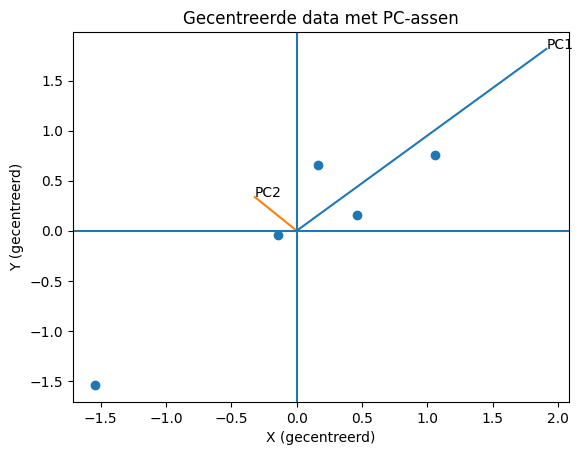

In [8]:
# --- 7) (Optioneel) Plotten ---------------------------------------------------
# Opmerking: uit commentaar halen om te plotten.
import matplotlib.pyplot as plt
fig = plt.figure()
plt.scatter(X_centered["X"], X_centered["Y"])
# PC-assen tekenen (geschaalde eigenvectoren voor zichtbaarheid)
for i in range(2):
    vec = eigvecs[:, i] * np.sqrt(eigvals[i]) * 2.0
    plt.plot([0, vec[0]], [0, vec[1]])
    plt.text(vec[0], vec[1], f"PC{i+1}")
plt.axhline(0); plt.axvline(0)
plt.title("Gecentreerde data met PC-assen")
plt.xlabel("X (gecentreerd)"); plt.ylabel("Y (gecentreerd)")
plt.show()